**importing libraries**

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression 
%matplotlib inline


In [2]:
ticker = "AAPL"
stock = yf.Ticker(ticker)
data = stock.history(period="1y")
data.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-03-28 00:00:00-04:00,220.708066,222.838779,216.735375,216.954422,39818600,0.0,0.0
2025-03-31 00:00:00-04:00,216.068255,224.640891,215.291641,221.166046,65299300,0.0,0.0
2025-04-01 00:00:00-04:00,218.856144,222.709345,217.950089,222.221481,36412700,0.0,0.0
2025-04-02 00:00:00-04:00,220.359602,224.212804,220.060901,222.918442,35905900,0.0,0.0
2025-04-03 00:00:00-04:00,204.648051,206.589601,200.376674,202.308258,103419000,0.0,0.0



**Data processing**


In [3]:
data = data.dropna()
data = data.reset_index()
data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2025-03-28 00:00:00-04:00,220.708066,222.838779,216.735375,216.954422,39818600,0.0,0.0
1,2025-03-31 00:00:00-04:00,216.068255,224.640891,215.291641,221.166046,65299300,0.0,0.0
2,2025-04-01 00:00:00-04:00,218.856144,222.709345,217.950089,222.221481,36412700,0.0,0.0
3,2025-04-02 00:00:00-04:00,220.359602,224.212804,220.060901,222.918442,35905900,0.0,0.0
4,2025-04-03 00:00:00-04:00,204.648051,206.589601,200.376674,202.308258,103419000,0.0,0.0


**visualize historical data**

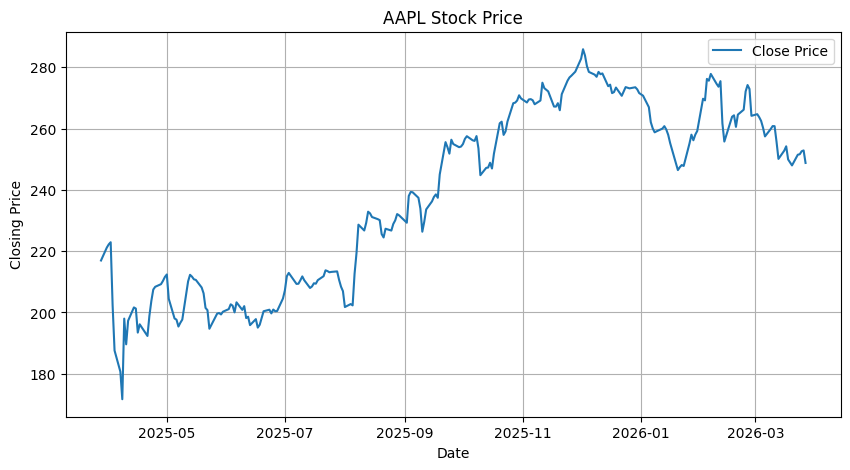

In [4]:
plt.figure(figsize=(10,5))
plt.plot(data['Date'], data['Close'], label='Close Price')
plt.title(f'{ticker} Stock Price')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.grid(True)
plt.legend()
plt.show()

**prepare data for prediction**

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [6]:
data['Days'] = np.arange(len(data))

x = data[['Days']]
y = data['Close']

x_train, x_test, y_train, Y_test = train_test_split(x,y, test_size=0.3, shuffle=False)

print(f"training data: {len(x_train)} rows")
print(f"testing data: {len(x_test)} rows")



training data: 175 rows
testing data: 76 rows


**Train model on training data**


Slope (m): 0.507736797443805
Intercept (b): 183.44904182830413


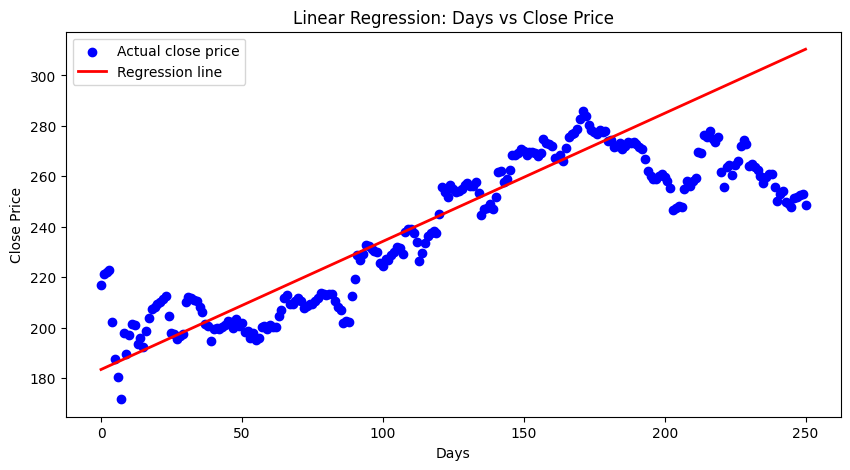

In [9]:
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print(f"Slope (m): {model.coef_[0]}")
print(f"Intercept (b): {model.intercept_}")

plt.figure(figsize=(10,5))
plt.scatter(x, y, color='blue', label='Actual close price')
plt.plot(x, model.predict(x), color='red', linewidth=2, label='Regression line')
plt.title("Linear Regression: Days vs Close Price")
plt.xlabel("Days")
plt.ylabel("Close Price")
plt.legend()
plt.show()
